In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, MiniBatchKMeans
import faiss

In [20]:
# The SIFT dataset vectors are stored in .fvecs format. 
# Each vector entry starts with an int32 dimension prefix followed by that many float32 components.

def read_ivecs(fname: str) -> np.ndarray:
    with open(fname, "rb") as f:
        data = np.fromfile(f, dtype=np.int32)

    dim = data[0]
    data = data.reshape(-1, dim + 1)

    return data[:, 1:]

def read_fvecs(fname: str) -> np.ndarray:
    with open(fname, "rb") as f:
        data = np.fromfile(f, dtype=np.int32)

    dim = data[0]
    data = data.reshape(-1, dim + 1)

    # reinterpret everything except first column as float32
    vectors = data[:, 1:].view(np.float32)

    return vectors

BASE = "C:\\Users\\adamm\\Desktop\\filtered-vector-search\\siftsmall\\siftsmall_base.fvecs"
QUERY = "C:\\Users\\adamm\\Desktop\\filtered-vector-search\\siftsmall\\siftsmall_query.fvecs"
TRUTH = "C:\\Users\\adamm\\Desktop\\filtered-vector-search\\siftsmall\\siftsmall_groundtruth.ivecs"

base_vectors = read_fvecs(BASE)
query_vectors = read_fvecs(QUERY)
truth_vectors = read_ivecs(TRUTH)

print(f"Dimensions of base: {base_vectors.shape}    Type: {base_vectors.dtype}")
print(f"Dimensions of query: {query_vectors.shape}    Type: {query_vectors.dtype}")
print(f"Dimensions of truth: {truth_vectors.shape}    Type: {truth_vectors.dtype}")

Dimensions of base: (10000, 128)    Type: float32
Dimensions of query: (100, 128)    Type: float32
Dimensions of truth: (100, 100)    Type: int32


In [21]:
n, d = base_vectors.shape
ids = np.arange(n)

In [ ]:
# We use this to generate the "positive correlation" predicate, where similar vectors have the same predicate value.
def base_clusters(vectors, k, seed=42):
    kmeans = MiniBatchKMeans(
        n_clusters=k,
        random_state=seed,
        batch_size=1024,
        max_iter=100
    )
    return kmeans.fit_predict(vectors)

# For negative correlation we assign each vector a random label drawn from the other
# clusters (i.e. exclude its own cluster).  This breaks the alignment
# between spatial proximity and attribute equality and produces
# genuinely anticorrelated data.
def generate_negative(cluster_labels, k, seed=42):
    rng = np.random.default_rng(seed)
    # draw a label in [0, k) but not equal to the original
    # vectorised trick: sample from k-1 values then shift upward when
    # the sampled value is >= original label.
    n = len(cluster_labels)
    choices = rng.integers(0, k-1, size=n)
    # bump up those that would collide with the original label
    choices += (choices >= cluster_labels).astype(np.int64)
    return choices

# For "medium" correlation, we can randomly flip some fraction of the positive correlation labels.
def add_noise(attr, noise_fraction, k, seed=42):
    rng = np.random.default_rng(seed)
    noisy = attr.copy()
    n = len(attr)
    noise_idx = rng.choice(n, int(noise_fraction * n), replace=False)
    noisy[noise_idx] = rng.integers(0, k, size=len(noise_idx))
    return noisy

# For uncorrelated, we can just assign random values.
def generate_uncorrelated(n, k, seed=42):
    rng = np.random.default_rng(seed)
    return rng.integers(0, k, size=n)

In [23]:
### Positive correlation
attr_lc_pos = base_clusters(base_vectors, k=5)
attr_hc_pos = base_clusters(base_vectors, k=500)

In [24]:
### Negative correlation
attr_lc_neg = generate_negative(attr_lc_pos, k=5)
attr_hc_neg = generate_negative(attr_hc_pos, k=500)

In [25]:
### Medium correlation (add noise to positive correlation)
attr_lc_med = add_noise(attr_lc_pos, noise_fraction=0.3, k=5)
attr_hc_med = add_noise(attr_hc_pos, noise_fraction=0.3, k=500)

In [26]:
### Random, uncorrelated
attr_lc_rand = generate_uncorrelated(n, k=5)
attr_hc_rand = generate_uncorrelated(n, k=500)

In [27]:
index_flat = faiss.IndexFlatL2(d)
index_flat.add(base_vectors)

print(f"Total vectors in index: {index_flat.ntotal}")

distances, indices = index_flat.search(query_vectors, 10)

Total vectors in index: 10000


In [28]:
def recall_at_k(pred, gt, k):
    correct = 0
    total = pred.shape[0]
    
    for i in range(total):
        top_k_results = pred[i][:k] 
        ground_truth_k_neighbors = gt[i][:k]
        correct += len(set(top_k_results) & set(ground_truth_k_neighbors)) > 0
    return correct / total

print(f'Recall@10: {recall_at_k(indices, truth_vectors, 10)}')

Recall@10: 1.0


In [ ]:
class CorrelationEstimator:
    def __init__(self, X, attr, n_clusters=40, random_state=42):
        self.X = X
        self.attr = attr

        # ---- Cluster once ----
        self.kmeans = KMeans(
            n_clusters=n_clusters,
            random_state=random_state,
            n_init="auto"
        )
        self.labels = self.kmeans.fit_predict(X)
        self.centroids = self.kmeans.cluster_centers_

        # ---- Precompute cluster -> indices mapping ----
        self.cluster_to_indices = {
            c: np.where(self.labels == c)[0]
            for c in range(n_clusters)
        }

    # --------------------------------------------------
    # Internal helpers
    # --------------------------------------------------

    def _nearest_clusters(self, q, top_L=1):
        distances = np.linalg.norm(self.centroids - q, axis=1)
        return np.argsort(distances)[:top_L]

    @staticmethod
    def _normalized_entropy(values):
        unique, counts = np.unique(values, return_counts=True)
        probs = counts / len(values)

        if len(probs) <= 1:
            return 0.0
 
        entropy = -np.sum(probs * np.log(probs + 1e-12))
        max_entropy = np.log(len(probs))
        return entropy / max_entropy

    @staticmethod
    def _binary_entropy(p):
        if p <= 0.0 or p >= 1.0:
            return 0.0
        H = -p * np.log(p) - (1 - p) * np.log(1 - p)
        return H / np.log(2)   # normalize to [0,1]
    
    @staticmethod
    def _dispersion(X_subset, mask):
        if np.sum(mask) < 2:
            return 0.0

        X_p = X_subset[mask]

        mu_p = X_p.mean(axis=0)
        D_p = np.mean(np.sum((X_p - mu_p) ** 2, axis=1))

        mu_all = X_subset.mean(axis=0)
        D_all = np.mean(np.sum((X_subset - mu_all) ** 2, axis=1))

        if D_all == 0:
            return 0.0

        return np.clip(1 - D_p / D_all, 0, 1)

    # --------------------------------------------------
    # Query-level correlation
    # --------------------------------------------------

    def compute_query_level(self, q, predicate_fn, top_L=5):
        # 1. Get local region
        cluster_ids = self._nearest_clusters(q, top_L)

        local_indices = np.concatenate(
            [self.cluster_to_indices[c] for c in cluster_ids]
        )

        if len(local_indices) < 5:
            return 0.0

        X_local = self.X[local_indices]
        attr_local = self.attr[local_indices]

        # 2. Apply predicate
        mask = predicate_fn(attr_local)

        if mask.sum() < 2:
            return 0.0

        selectivity = mask.mean()

        # 3. Structural component
        H_bin = self._binary_entropy(selectivity)
        score_struct = 1 - H_bin

        # 4. Dispersion component
        disp = self._dispersion(X_local, mask)

        # 5. Final correlation
        corr_q = score_struct * disp

        return float(np.clip(corr_q, 0, 1))

In [33]:
# Is the predicate locally skewed? (low entropy)
# Are predicate embeddings locally tight? (high dispersion)
# Correlation is high only if BOTH hold.

### Build estimators for each attribute type
est_lc_pos = CorrelationEstimator(base_vectors, attr_lc_pos)
est_lc_neg = CorrelationEstimator(base_vectors, attr_lc_neg)
est_lc_med = CorrelationEstimator(base_vectors, attr_lc_med)
est_lc_rand = CorrelationEstimator(base_vectors, attr_lc_rand)

### Sample queries
rng = np.random.default_rng(42)
query_indices = rng.choice(len(query_vectors), size=100, replace=False)
sample_queries = query_vectors[query_indices]

def make_predicate(value):
    return lambda a: a == value

def compute_distribution(estimator, attr):
    values = []
    for qi, q in zip(query_indices, sample_queries):
        pred_value = attr[qi]   # aligned predicate
        pred = make_predicate(pred_value)
        values.append(estimator.compute_query_level(q, pred))
    return values

corr_pos = compute_distribution(est_lc_pos, attr_lc_pos)
corr_rand = compute_distribution(est_lc_rand, attr_lc_rand)
corr_neg = compute_distribution(est_lc_neg, attr_lc_neg)
corr_med = compute_distribution(est_lc_med, attr_lc_med)


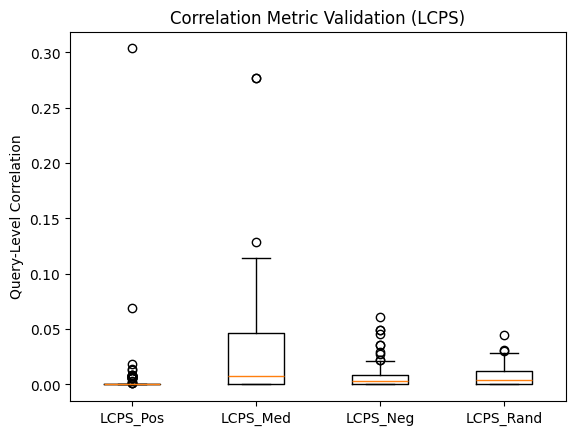

In [37]:
plt.figure()
plt.boxplot([corr_pos, corr_med, corr_neg, corr_rand])
plt.xticks([1,2,3,4], ["LCPS_Pos", "LCPS_Med", "LCPS_Neg", "LCPS_Rand"])
plt.ylabel("Query-Level Correlation")
plt.title("Correlation Metric Validation (LCPS)")
plt.show()